## Import Packages 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import json

## Load Dataset

In [2]:
data_path = './data/cleaned.xlsx'
df = pd.read_excel(data_path)

## 1. Customer profiles

In [3]:
analysis_df = df.dropna(subset=['gender', 'age', 'membership_tier', 'device', 'payment_method']).copy()

In [4]:
profile_summary = {
    "Customer count": analysis_df["customer_id"].nunique(),
    "Age average": analysis_df["age"].mean(),
    "Age median": analysis_df["age"].median(),
    "Most common gender": analysis_df["gender"].mode().map({'M':'Male', 'F':'Female'}).iloc[0],
    "Most common membership": analysis_df["membership_tier"].mode().iloc[0],
    "Most common device": analysis_df["device"].mode().iloc[0],
    "Most common payment method": analysis_df["payment_method"].mode().iloc[0]
}
profile_table = pd.Series(profile_summary)
display(profile_table)

Customer count                           60
Age average                            43.7
Age median                             45.0
Most common gender                     Male
Most common membership                 Gold
Most common device                  Android
Most common payment method    Online Wallet
dtype: object

### Most common gender

In [5]:
gender_counts = analysis_df['gender'].value_counts()
print("Most common gender:", gender_counts.idxmax())
print(gender_counts)

Most common gender: M
gender
M    35
F    25
Name: count, dtype: int64


### Age

In [6]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

analysis_df['age_group'] = pd.cut(
    analysis_df['age'],
    bins=bins,
    labels=labels,
    right=True
)
age_counts = analysis_df['age_group'].value_counts().sort_index()

### Membership

In [7]:
membership_counts = analysis_df['membership_tier'].value_counts()

### Device

In [8]:
device_counts = analysis_df['device'].value_counts()

### Payment method

In [9]:
payment_method_counts = analysis_df['payment_method'].value_counts()

### Bar charts

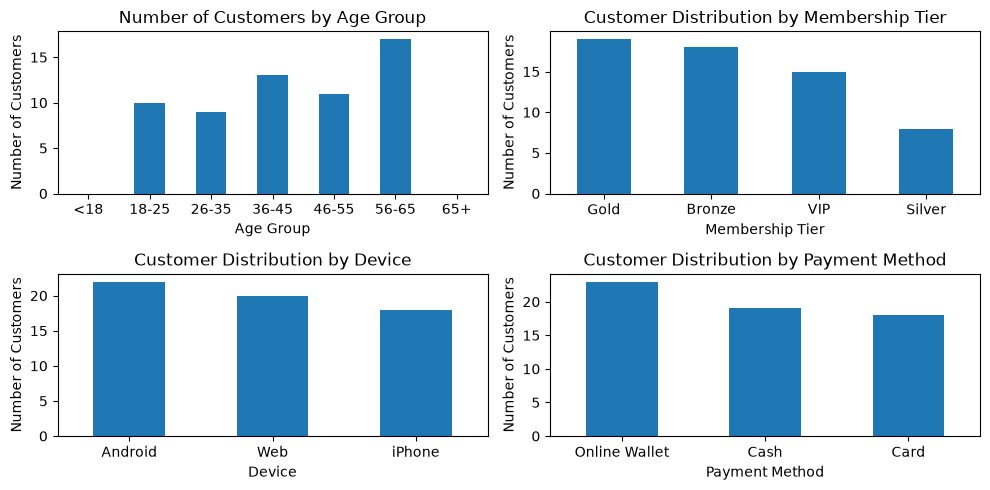

In [10]:
fig, axes = plt.subplots(2,2, figsize=(10, 5))

for col_title, col_value_counts, ax, x_label in [
    ('Customer Distribution by Age Group', age_counts, axes[0, 0], 'Age Group'),
    ('Customer Distribution by Membership Tier', membership_counts, axes[0, 1], 'Membership Tier'),
    ('Customer Distribution by Device', device_counts, axes[1, 0], 'Device'),
    ('Customer Distribution by Payment Method', payment_method_counts, axes[1, 1], 'Payment Method'),
]:
    col_value_counts.plot(kind='bar', ax=ax)
    ax.set_title(col_title);
    ax.set_xlabel(x_label);
    ax.set_ylabel('Number of Customers');
    ax.tick_params(axis='x', rotation=0);
    
plt.tight_layout()
plt.show()

## 2. City for invest